In [1]:
import os
import sys
import warnings

sys.path.append(os.path.abspath("../scripts"))

import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    precision_score, recall_score
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer

import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format = "retina"
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12

from data_preprocessing import preprocess_for_nn
from boosting_models import run_lr_tuning, run_catboost_tuning, run_lgbm_tuning
from deep_model import TabularDataset, TABMLP, train, evaluate

warnings.filterwarnings("ignore")

## Датасет [Heart](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction)

In [2]:
import kagglehub

path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction") + "/heart.csv"

df = pd.read_csv(path)
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
X = df.drop(columns=["HeartDisease"])
y = df["HeartDisease"]
le = LabelEncoder()
y = le.fit_transform(y)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y, shuffle=True)
X_test, X_valid, y_test, y_valid = train_test_split(X_test, y_test, test_size=0.5, random_state=0, stratify=y_test, shuffle=True)

In [5]:
categorical_features = ["Sex", "ChestPainType", "FastingBS", "RestingECG", "ExerciseAngina", "ST_Slope"]
numerical_features = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
column_transformer = ColumnTransformer([
        ("ohe", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("scaling", StandardScaler(), numerical_features)
])

In [6]:
model_lr = run_lr_tuning(X_train, y_train, X_valid, y_valid, column_transformer)
y_pred_lr = model_lr.predict(X_test)
print("ROC-AUC = %.4f" % roc_auc_score(y_test, model_lr.predict_proba(X_test)[:, 1]))
print("F1 = %.4f" % f1_score(y_test, y_pred_lr))
print("Accuracy = %.4f" % accuracy_score(y_test, y_pred_lr))
print("Precision = %.4f" % precision_score(y_test, y_pred_lr))
print("Recall = %.4f" % recall_score(y_test, y_pred_lr))

[I 2025-04-14 19:33:18,449] A new study created in memory with name: logistic_regression_optimization
[I 2025-04-14 19:33:18,505] Trial 0 finished with value: 0.921090387374462 and parameters: {'penalty': 'l2', 'C': 0.01}. Best is trial 0 with value: 0.921090387374462.
[I 2025-04-14 19:33:18,520] Trial 1 finished with value: 0.8127690100430416 and parameters: {'penalty': 'l1', 'C': 0.01}. Best is trial 0 with value: 0.921090387374462.
[I 2025-04-14 19:33:18,539] Trial 2 finished with value: 0.8866571018651364 and parameters: {'penalty': 'l2', 'C': 0.001}. Best is trial 0 with value: 0.921090387374462.
[I 2025-04-14 19:33:18,555] Trial 3 finished with value: 0.5 and parameters: {'penalty': 'l1', 'C': 0.0001}. Best is trial 0 with value: 0.921090387374462.
[I 2025-04-14 19:33:18,569] Trial 4 finished with value: 0.9512195121951219 and parameters: {'penalty': 'l2', 'C': 0.1}. Best is trial 4 with value: 0.9512195121951219.
[I 2025-04-14 19:33:18,590] Trial 5 finished with value: 0.5 and p

ROC-AUC = 0.9440
F1 = 0.8750
Accuracy = 0.8696
Precision = 0.9333
Recall = 0.8235


In [7]:
model_cb = run_catboost_tuning(X_train, y_train, X_valid, y_valid, column_transformer)
y_pred_cb = model_cb.predict(X_test)
print("ROC-AUC = %.4f" % roc_auc_score(y_test, model_cb.predict_proba(X_test)[:, 1]))
print("F1 = %.4f" % f1_score(y_test, y_pred_cb))
print("Accuracy = %.4f" % accuracy_score(y_test, y_pred_cb))
print("Precision = %.4f" % precision_score(y_test, y_pred_cb))
print("Recall = %.4f" % recall_score(y_test, y_pred_cb))

[I 2025-04-14 19:33:19,093] A new study created in memory with name: catboost_optimization
[I 2025-04-14 19:33:19,654] Trial 0 finished with value: 0.9230033476805357 and parameters: {'depth': 4, 'learning_rate': 0.3, 'l2_leaf_reg': 0.001}. Best is trial 0 with value: 0.9230033476805357.
[I 2025-04-14 19:33:20,148] Trial 1 finished with value: 0.9143950263032041 and parameters: {'depth': 4, 'learning_rate': 0.3, 'l2_leaf_reg': 0.1}. Best is trial 0 with value: 0.9230033476805357.
[I 2025-04-14 19:33:22,984] Trial 2 finished with value: 0.940698230511717 and parameters: {'depth': 8, 'learning_rate': 0.01, 'l2_leaf_reg': 0.001}. Best is trial 2 with value: 0.940698230511717.
[I 2025-04-14 19:33:23,319] Trial 3 finished with value: 0.9574366331898614 and parameters: {'depth': 2, 'learning_rate': 0.01, 'l2_leaf_reg': 0.001}. Best is trial 3 with value: 0.9574366331898614.
[I 2025-04-14 19:33:24,377] Trial 4 finished with value: 0.9344811095169776 and parameters: {'depth': 6, 'learning_rate

ROC-AUC = 0.9517
F1 = 0.8958
Accuracy = 0.8913
Precision = 0.9556
Recall = 0.8431


In [8]:
model_lgbm = run_lgbm_tuning(X_train, y_train, X_valid, y_valid, column_transformer)
y_pred_lgbm = model_lgbm.predict(X_test)
print("ROC-AUC = %.4f" % roc_auc_score(y_test, model_lgbm.predict_proba(X_test)[:, 1]))
print("F1 = %.4f" % f1_score(y_test, y_pred_lgbm))
print("Accuracy = %.4f" % accuracy_score(y_test, y_pred_lgbm))
print("Precision = %.4f" % precision_score(y_test, y_pred_lgbm))
print("Recall = %.4f" % recall_score(y_test, y_pred_lgbm))

[I 2025-04-14 19:34:12,112] A new study created in memory with name: lightgbm_optimization
[I 2025-04-14 19:34:13,088] Trial 0 finished with value: 0.9172644667623148 and parameters: {'num_leaves': 1024, 'reg_alpha': 0.01, 'reg_lambda': 10.0, 'learning_rate': 0.3}. Best is trial 0 with value: 0.9172644667623148.
[I 2025-04-14 19:34:14,442] Trial 1 finished with value: 0.9258727881396461 and parameters: {'num_leaves': 256, 'reg_alpha': 1e-06, 'reg_lambda': 1e-06, 'learning_rate': 0.03}. Best is trial 1 with value: 0.9258727881396461.
[I 2025-04-14 19:34:14,843] Trial 2 finished with value: 0.9120038259206122 and parameters: {'num_leaves': 512, 'reg_alpha': 1e-08, 'reg_lambda': 0.001, 'learning_rate': 0.3}. Best is trial 1 with value: 0.9258727881396461.
[I 2025-04-14 19:34:15,007] Trial 3 finished with value: 0.951219512195122 and parameters: {'num_leaves': 256, 'reg_alpha': 10.0, 'reg_lambda': 0.01, 'learning_rate': 0.03}. Best is trial 3 with value: 0.951219512195122.
[I 2025-04-14 19

ROC-AUC = 0.9498
F1 = 0.8750
Accuracy = 0.8696
Precision = 0.9333
Recall = 0.8235


In [9]:
X_train, X_valid, X_test = preprocess_for_nn(X_train, X_valid, X_test, categorical_features, numerical_features)

In [10]:
trainset = TabularDataset(X_train, y_train, categorical_features)
valset = TabularDataset(X_valid, y_valid, categorical_features)
testset  = TabularDataset(X_test, y_test, categorical_features)

batch_size = 256
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(valset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(testset, batch_size=batch_size, shuffle=False)

In [11]:
cat_dims = [int(X_train[col].nunique()) for col in categorical_features]
emb_dims = [(x, min(50, (x + 1) // 2)) for x in cat_dims]

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


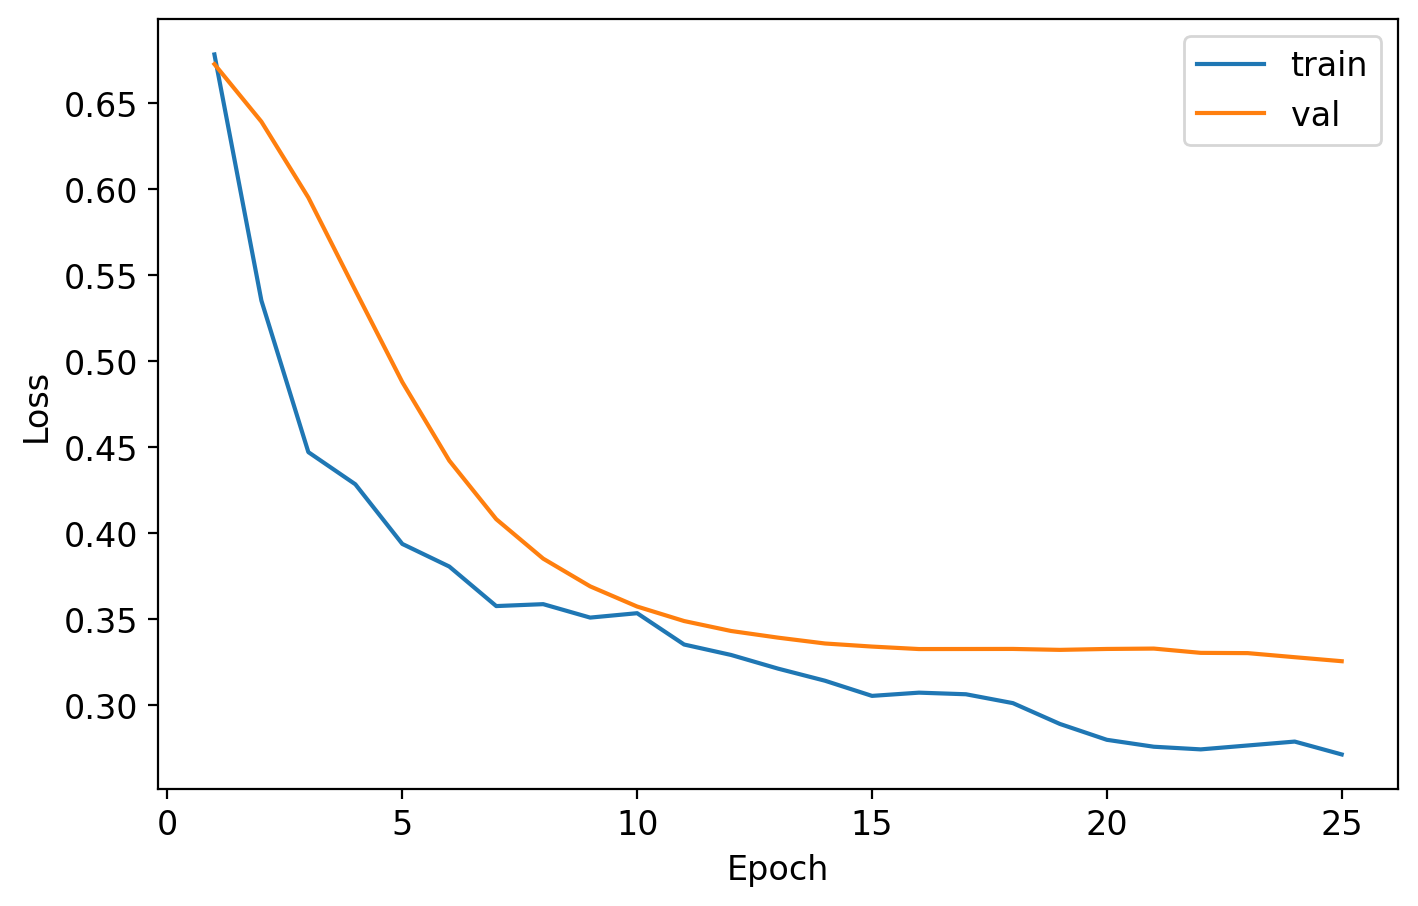

Epoch 25: train loss = 0.2714; valid loss = 0.3256


In [20]:
net = TABMLP(len(numerical_features), emb_dims).to(device)
optimizer = optim.Adam(net.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

train(net, optimizer, 25, train_loader, val_loader, criterion, device)

In [21]:
y_true, y_prob, y_pred = evaluate(net, test_loader, device)
print("ROC-AUC = %.4f" % roc_auc_score(y_test, y_prob))
print("F1 = %.4f" % f1_score(y_test, y_pred))
print("Accuracy = %.4f" % accuracy_score(y_test, y_pred))
print("Precision = %.4f" % precision_score(y_test, y_pred))
print("Recall = %.4f" % recall_score(y_test, y_pred))

ROC-AUC = 0.9627
F1 = 0.9053
Accuracy = 0.9022
Precision = 0.9773
Recall = 0.8431
